# Setting

In [1]:
import pandas as pd
import numpy as np
from matplotlib.gridspec import GridSpec
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

In [21]:
# Paths
BASE_DIR = Path('../')
NETWORK_DIR = BASE_DIR / 'result' / 'networks'
OUTPUT_DIR = BASE_DIR / 'result'
FIGURES_DIR = OUTPUT_DIR / 'figures'
TABLES_DIR = OUTPUT_DIR / 'tables'

# Create directories
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# Set style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 10

In [4]:
M_GROUPS = [
    ('남성', '청년층(19-39세)', 'MetS(+)'),
    ('남성', '중년층(40-59세)', 'MetS(+)'),
    ('남성', '장년층(60-74세)', 'MetS(+)'),
    ('남성', '중년층(40-59세)', 'MetS(-)'),
    ('남성', '청년층(19-39세)', 'MetS(-)'),
    ('남성', '장년층(60-74세)', 'MetS(-)'),
]
F_GROUPS = [
    ('여성', '중년층(40-59세)', 'MetS(+)'),
    ('여성', '장년층(60-74세)', 'MetS(+)'),
    ('여성', '청년층(19-39세)', 'MetS(-)'),
    ('여성', '중년층(40-59세)', 'MetS(-)'),
    ('여성', '장년층(60-74세)', 'MetS(-)'),
]

M_GROUP_LABELS = [
    'Male_Young_MetS(+)',
    'Male_Middle_MetS(+)',
    'Male_Older_MetS(+)',
    'Male_Young_MetS(-)',
    'Male_Middle_MetS(-)',
    'Male_Older_MetS(-)',
]
F_GROUP_LABELS = [
    'Female_Middle_MetS(+)',
    'Female_Older_MetS(+)',
    'Female_Young_MetS(-)',
    'Female_Middle_MetS(-)',
    'Female_Older_MetS(-)',
]

GROUPS = M_GROUPS + F_GROUPS
GROUP_LABELS = M_GROUP_LABELS + F_GROUP_LABELS

FOOD_ABBREV = {
    'Grain Products': 'GRAIN',
    'Protein Foods': 'PROTEIN',
    'Vegetables': 'VEG',
    'Dairy Products': 'DAIRY',
    'Fruits': 'FRUIT',
    'Fried Foods': 'FRIED',
    'High Fat Meat': 'HIGH_FAT_MEAT',
    'Processed Foods': 'Processed',
    'Sugar-Sweetened Beverages': 'SSB',
    'Additional Salt Use': 'ADD_SALT',
    'Salty Food Consumption': 'SALTY',
    'Sweet Food Consumption': 'SWEET'
}

def load_network(sex, age_group, mets_status):
    filename = f"ggm_network_{sex}_{age_group}_{mets_status}.gexf"
    filepath = NETWORK_DIR / filename
    if filepath.exists():
        return nx.read_gexf(str(filepath))
    return None

def load_statistics():
    stats_file = NETWORK_DIR / 'ggm_network_summary.csv'
    if stats_file.exists():
        return pd.read_csv(stats_file)
    return None

def load_all_community_data():
    summary_df = pd.read_csv(NETWORK_DIR / 'ggm_network_summary.csv')
    
    all_data = []
    for _, row in summary_df.iterrows():
        group = row['Group']
        
        community_file = NETWORK_DIR / f"ggm_network_{group}_communities.csv"
        if community_file.exists():
            comm_df = pd.read_csv(community_file)
            comm_df['Group'] = group
            all_data.append(comm_df)
    
    return pd.concat(all_data, ignore_index=True) if all_data else pd.DataFrame()

def load_partial_corr_matrix(sex, age_group, mets_status):
    filename = f"ggm_network_{sex}_{age_group}_{mets_status}_partial_corr.csv"
    filepath = NETWORK_DIR / filename
    
    if filepath.exists():
        return pd.read_csv(filepath, index_col=0)
    return None

# TABLES

## TABLE 1: Sample Characteristics

## TABLE 2: Network Metrics Summary


In [5]:
stats_df = load_statistics()
combined_data = []

for idx, (sex, age_group, mets_status) in enumerate(GROUPS):
    G = load_network(sex, age_group, mets_status)    
    group_name = f"{sex}_{age_group}_{mets_status}"
    group_label = GROUP_LABELS[idx]
    
    stats_row = stats_df[
        (stats_df['Sex'] == sex) & 
        (stats_df['Age_Group'] == age_group) & 
        (stats_df['MetS_Status'] == mets_status)
    ]
    
    if len(stats_row) == 0:
        continue
    
    stats_row = stats_row.iloc[0]
    
    # Basic network metrics
    n_nodes = G.number_of_nodes()
    n_edges = G.number_of_edges()
    density = nx.density(G)
    
    try:
        avg_clustering = nx.average_clustering(G)
    except:
        avg_clustering = 0.0
    
    avg_degree = sum(dict(G.degree()).values()) / n_nodes if n_nodes > 0 else 0
    
    # Calculate centralities
    degree_cent = nx.degree_centrality(G)
    
    try:
        betweenness_cent = nx.betweenness_centrality(G)
    except:
        betweenness_cent = {node: 0 for node in G.nodes()}
    
    try:
        closeness_cent = nx.closeness_centrality(G)
    except:
        closeness_cent = {node: 0 for node in G.nodes()}
    
    top_degree = sorted(degree_cent.items(), key=lambda x: x[1], reverse=True)[:3]
    top_betweenness = sorted(betweenness_cent.items(), key=lambda x: x[1], reverse=True)[:3]
    top_closeness = sorted(closeness_cent.items(), key=lambda x: x[1], reverse=True)[:3]
    
    # Combine all data
    row_data = {
        'Group': group_label,
        'N': int(stats_row['N_Samples']),
        'Nodes': n_nodes,
        'Edges': n_edges,
        'Density': f"{density:.3f}",
        'Clustering': f"{avg_clustering:.3f}",
        'Avg Degree': f"{avg_degree:.2f}",
        'Modularity': f"{stats_row['Modularity']:.3f}",
        'N Communities': int(stats_row['N_Communities']),
        'Alpha': f"{stats_row['Alpha']:.4f}",
        # Top 3 Degree Centrality
        'Hub 1 (Degree)': f"{top_degree[0][0]} ({top_degree[0][1]:.3f})" if len(top_degree) > 0 else '',
        'Hub 2 (Degree)': f"{top_degree[1][0]} ({top_degree[1][1]:.3f})" if len(top_degree) > 1 else '',
        'Hub 3 (Degree)': f"{top_degree[2][0]} ({top_degree[2][1]:.3f})" if len(top_degree) > 2 else '',
        # Top 3 Betweenness Centrality
        'Hub 1 (Betweenness)': f"{top_betweenness[0][0]} ({top_betweenness[0][1]:.3f})" if len(top_betweenness) > 0 else '',
        'Hub 2 (Betweenness)': f"{top_betweenness[1][0]} ({top_betweenness[1][1]:.3f})" if len(top_betweenness) > 1 else '',
        'Hub 3 (Betweenness)': f"{top_betweenness[2][0]} ({top_betweenness[2][1]:.3f})" if len(top_betweenness) > 2 else '',
        # Top 3 Closeness Centrality
        'Hub 1 (Closeness)': f"{top_closeness[0][0]} ({top_closeness[0][1]:.3f})" if len(top_closeness) > 0 else '',
        'Hub 2 (Closeness)': f"{top_closeness[1][0]} ({top_closeness[1][1]:.3f})" if len(top_closeness) > 1 else '',
        'Hub 3 (Closeness)': f"{top_closeness[2][0]} ({top_closeness[2][1]:.3f})" if len(top_closeness) > 2 else '',
    }
    
    combined_data.append(row_data)

df_combined = pd.DataFrame(combined_data)
output_csv = TABLES_DIR / 'Table_2_Network_Metrics_GGM.csv'
df_combined.to_csv(output_csv, index=False)
df_combined

,Group,N,Nodes,Edges,Density,Clustering,Avg Degree,Modularity,N Communities,Alpha,Hub 1 (Degree),Hub 2 (Degree),Hub 3 (Degree),Hub 1 (Betweenness),Hub 2 (Betweenness),Hub 3 (Betweenness),Hub 1 (Closeness),Hub 2 (Closeness),Hub 3 (Closeness)
0,Male_Young_MetS(+),516,12,8,0.121,0.194,1.33,0.616,6,0.1238,Processed Foods (0.273),Vegetables (0.182),Fried Foods (0.182),Processed Foods (0.073),Sugar-Sweetened Beverages (0.055),Vegetables (0.018),Processed Foods (0.291),Sugar-Sweetened Beverages (0.242),Fried Foods (0.208)
1,Male_Middle_MetS(+),2938,12,8,0.121,0.000,1.33,0.658,4,0.1238,Protein Foods (0.182),Fried Foods (0.182),Processed Foods (0.182),Processed Foods (0.073),Fried Foods (0.055),Sugar-Sweetened Beverages (0.055),Processed Foods (0.242),Fried Foods (0.208),Sugar-Sweetened Beverages (0.208)
2,Male_Older_MetS(+),971,12,6,0.091,0.000,1.00,0.618,7,0.1638,Fried Foods (0.182),Processed Foods (0.182),Sugar-Sweetened Beverages (0.182),Processed Foods (0.073),Fried Foods (0.055),Sugar-Sweetened Beverages (0.055),Processed Foods (0.242),Fried Foods (0.208),Sugar-Sweetened Beverages (0.208)
3,Male_Young_MetS(-),4737,12,7,0.106,0.000,1.17,0.589,6,0.1238,Protein Foods (0.182),Fried Foods (0.182),Processed Foods (0.182),Processed Foods (0.073),Fried Foods (0.055),Sugar-Sweetened Beverages (0.055),Processed Foods (0.242),Fried Foods (0.208),Sugar-Sweetened Beverages (0.208)
4,Male_Middle_MetS(-),1963,12,9,0.136,0.194,1.50,0.660,5,0.1238,Processed Foods (0.273),Protein Foods (0.182),Fried Foods (0.182),Processed Foods (0.073),Sugar-Sweetened Beverages (0.055),Protein Foods (0.018),Processed Foods (0.291),Sugar-Sweetened Beverages (0.242),Fried Foods (0.208)
5,Male_Older_MetS(-),1169,12,6,0.091,0.000,1.00,0.653,6,0.1638,Protein Foods (0.182),Fried Foods (0.182),Processed Foods (0.182),Fried Foods (0.036),Processed Foods (0.036),Protein Foods (0.018),Fried Foods (0.205),Processed Foods (0.205),Protein Foods (0.182)
6,Female_Middle_MetS(+),758,12,7,0.106,0.000,1.17,0.629,6,0.1238,Fried Foods (0.182),Processed Foods (0.182),Sweet Food Consumption (0.182),Processed Foods (0.073),Fried Foods (0.055),Sweet Food Consumption (0.055),Processed Foods (0.242),Fried Foods (0.208),Sweet Food Consumption (0.208)
7,Female_Older_MetS(+),680,12,6,0.091,0.250,1.00,0.643,7,0.1238,Protein Foods (0.182),Fried Foods (0.182),High Fat Meat (0.182),Protein Foods (0.018),Grain Products (0.000),Vegetables (0.000),Protein Foods (0.182),Fried Foods (0.182),High Fat Meat (0.182)
8,Female_Young_MetS(-),2519,12,5,0.076,0.000,0.83,0.643,7,0.1638,High Fat Meat (0.182),Processed Foods (0.182),Protein Foods (0.091),High Fat Meat (0.036),Processed Foods (0.036),Grain Products (0.000),High Fat Meat (0.205),Processed Foods (0.205),Fried Foods (0.136)
9,Female_Middle_MetS(-),5629,12,7,0.106,0.000,1.17,0.597,6,0.1238,Processed Foods (0.273),Protein Foods (0.182),Fried Foods (0.182),Processed Foods (0.091),Fried Foods (0.055),Protein Foods (0.018),Processed Foods (0.291),Fried Foods (0.242),Protein Foods (0.182)


## TABLE S1: Network Edge List

In [6]:
all_edges = []

for sex, age_group, mets_status in GROUPS:
    G = load_network(sex, age_group, mets_status)
    
    if G is None or G.number_of_edges() == 0:
        continue
    
    group_label = f"{sex}_{age_group}_{mets_status}"
    
    for u, v, data in G.edges(data=True):
        weight = data.get('weight', 0)
        partial_corr = data.get('partial_corr', weight)
        
        all_edges.append({
            'Group': group_label,
            'Node 1': u,
            'Node 2': v,
            'Partial Correlation': f"{partial_corr:.4f}",
            'Absolute Weight': f"{weight:.4f}"
        })

df_edges = pd.DataFrame(all_edges)

output_file = TABLES_DIR / 'Supplementary_Table_S1_Edge_Lists_GGM.csv'
df_edges.to_csv(output_file, index=False)
df_edges

,Group,Node 1,Node 2,Partial Correlation,Absolute Weight
0,남성_청년층(19-39세)_MetS(+),Grain Products,Vegetables,0.1104,0.1104
1,남성_청년층(19-39세)_MetS(+),Protein Foods,Vegetables,0.2917,0.2917
2,남성_청년층(19-39세)_MetS(+),Fried Foods,High Fat Meat,0.1894,0.1894
3,남성_청년층(19-39세)_MetS(+),Fried Foods,Processed Foods,0.1825,0.1825
4,남성_청년층(19-39세)_MetS(+),High Fat Meat,Processed Foods,0.1679,0.1679
...,...,...,...,...,...
67,여성_중년층(40-59세)_MetS(-),Processed Foods,Sweet Food Consumption,0.1239,0.1239
68,여성_중년층(40-59세)_MetS(-),Additional Salt Use,Salty Food Consumption,0.1742,0.1742
69,여성_장년층(60-74세)_MetS(-),Protein Foods,Vegetables,0.3064,0.3064
70,여성_장년층(60-74세)_MetS(-),Processed Foods,Sweet Food Consumption,0.1251,0.1251


## TABLE S2: Community analysis

In [7]:
def categorize_foods(food_list):
    healthy = []
    processed = []
    salt_related = []
    
    for food in food_list:
        if food in ['Grain Products', 'Protein Foods', 'Vegetables', 'Dairy Products', 'Fruits']:
            healthy.append(food)
        elif food in ['Fried Foods', 'High Fat Meat', 'Processed Foods', 
                      'Sugar-Sweetened Beverages', 'Sweet Food Consumption']:
            processed.append(food)
        else:
            salt_related.append(food)
    
    return healthy, processed, salt_related

def interpret_community(foods):
    healthy, processed, salt_related = categorize_foods(foods)
    
    if len(healthy) >= len(processed) and len(healthy) >= len(salt_related):
        if len(healthy) >= 4:
            return "Traditional Korean Diet Pattern"
        else:
            return "Mixed Healthy Pattern"
    elif len(processed) > len(healthy) and len(processed) >= len(salt_related):
        if len(processed) >= 4:
            return "Western/Processed Food Pattern"
        else:
            return "Mixed Processed Pattern"
    elif len(salt_related) >= 2:
        return "High Sodium Pattern"
    else:
        return "Mixed Pattern"

summary_df = pd.read_csv(NETWORK_DIR / 'ggm_network_summary.csv')

all_rows = []

for idx, (sex, age_group, mets_status) in enumerate(GROUPS):
    group = f"{sex}_{age_group}_{mets_status}"
    
    # Load community file
    comm_file = NETWORK_DIR / f"ggm_network_{group}_communities.csv"
    if not comm_file.exists():
        print(f"Warning: Community file not found: {comm_file}")
        continue
    
    comm_df = pd.read_csv(comm_file)
    
    # Get modularity and n_communities
    modularity = summary_df[summary_df['Group'] == group]['Modularity'].values[0]
    n_communities = len(comm_df)
    group_english = GROUP_LABELS[idx]
    
    # Process each community
    for _, row in comm_df.iterrows():
        comm_id = row['community_id']
        size = row['size']
        nodes = row['nodes'].split('; ')
        internal_edges = row['internal_edges']
        internal_density = row['internal_density']
        
        # Categorize foods
        healthy, processed, salt_related = categorize_foods(nodes)
        interpretation = interpret_community(nodes)
        
        # Format food lists
        healthy_str = ', '.join(healthy) if healthy else '-'
        processed_str = ', '.join(processed) if processed else '-'
        salt_str = ', '.join(salt_related) if salt_related else '-'
        
        all_rows.append({
            'Group': group_english,
            'Total Communities': n_communities,
            'Modularity': f"{modularity:.3f}",
            'Community ID': comm_id,
            'Size': size,
            'Internal Edges': internal_edges,
            'Internal Density': f"{internal_density:.3f}",
            'Healthy Foods': healthy_str,
            'Processed/Unhealthy Foods': processed_str,
            'Salt-related Foods': salt_str,
            'Dietary Pattern': interpretation
        })

# Create DataFrame
table_df = pd.DataFrame(all_rows)
output_csv = TABLES_DIR / 'Supplementary_Table_S2_Community_Characteristics.csv'
table_df.to_csv(output_csv, index=False)
table_df

""


## TABLE S3:

In [8]:
network_summary = pd.read_csv(OUTPUT_DIR / 'networks/ggm_network_summary.csv')

def get_top3_hubs(group_row):
    hubs = [
        group_row['Hub_1_Name'],
        group_row['Hub_2_Name'],
        group_row['Hub_3_Name']
    ]
    return [h for h in hubs if pd.notna(h)]

def classify_hubs(mets_plus_hubs, mets_minus_hubs):
    mets_plus_set = set(mets_plus_hubs)
    mets_minus_set = set(mets_minus_hubs)
    
    shared = list(mets_plus_set & mets_minus_set)
    risk = list(mets_plus_set - mets_minus_set)
    protective = list(mets_minus_set - mets_plus_set)
    
    return shared, risk, protective

def format_hub_list(hubs):
    if not hubs:
        return 'None'
    return ', '.join(hubs)

def calculate_network_diff(plus_row, minus_row):
    edge_diff = int(plus_row['N_Edges']) - int(minus_row['N_Edges'])
    mod_diff = plus_row['Modularity'] - minus_row['Modularity']
    
    edge_sign = '+' if edge_diff > 0 else ''
    mod_sign = '+' if mod_diff > 0 else ''
    
    return f"Δ Edges={edge_sign}{edge_diff}, Δ Modularity={mod_sign}{mod_diff:.3f}"

def generate_coaching_strategy(risk_hubs, protective_hubs):
    parts = []
    if risk_hubs:
        parts.append(f"Reduce: {', '.join(risk_hubs)}")
    if protective_hubs:
        parts.append(f"Promote: {', '.join(protective_hubs)}")
    
    return " | ".join(parts)

groups_info = [
    ('남성', '청년층(19-39세)', 'Male', 'Young (19-39y)'),
    ('남성', '중년층(40-59세)', 'Male', 'Middle-aged (40-59y)'),
    ('남성', '장년층(60-74세)', 'Male', 'Older (60-74y)'),
    ('여성', '청년층(19-39세)', 'Female', 'Young (19-39y)'),
    ('여성', '중년층(40-59세)', 'Female', 'Middle-aged (40-59y)'),
    ('여성', '장년층(60-74세)', 'Female', 'Older (60-74y)'),
]

table_s3_data = []

for sex_kr, age_kr, sex_en, age_en in groups_info:
    group_plus = f"{sex_kr}_{age_kr}_MetS(+)"
    group_minus = f"{sex_kr}_{age_kr}_MetS(-)"
    
    plus_rows = network_summary[network_summary['Group'] == group_plus]
    minus_rows = network_summary[network_summary['Group'] == group_minus]
    
    if plus_rows.empty or minus_rows.empty:
        continue
    
    plus_row = plus_rows.iloc[0]
    minus_row = minus_rows.iloc[0]
    
    mets_plus_hubs = get_top3_hubs(plus_row)
    mets_minus_hubs = get_top3_hubs(minus_row)
    
    shared_hubs, risk_hubs, protective_hubs = classify_hubs(mets_plus_hubs, mets_minus_hubs)
    
    network_diff = calculate_network_diff(plus_row, minus_row)
    coaching_strategy = generate_coaching_strategy(risk_hubs, protective_hubs)
    
    table_s3_data.append({
        'Sex': sex_en,
        'Age_Group': age_en,
        'N_MetS_Plus': int(plus_row['N_Samples']),
        'N_MetS_Minus': int(minus_row['N_Samples']),
        'MetS_Plus_Hubs': format_hub_list(mets_plus_hubs),
        'MetS_Minus_Hubs': format_hub_list(mets_minus_hubs),
        'Shared_Hubs': format_hub_list(shared_hubs),
        'Risk_Hubs_in_MetS': format_hub_list(risk_hubs),
        'Protective_Hubs_in_Healthy': format_hub_list(protective_hubs),
        'Network_Difference': network_diff,
        'Personalized_Coaching_Strategy': coaching_strategy
    })

table_s3 = pd.DataFrame(table_s3_data)
table_s3.to_csv(TABLES_DIR / 'Table_S3_Personalized_Coaching_Strategies.csv', index=False)
table_s3

,Sex,Age_Group,N_MetS_Plus,N_MetS_Minus,MetS_Plus_Hubs,MetS_Minus_Hubs,Shared_Hubs,Risk_Hubs_in_MetS,Protective_Hubs_in_Healthy,Network_Difference,Personalized_Coaching_Strategy
0,Male,Young (19-39y),516,1963,"Processed Foods, Vegetables, Fried Foods","Processed Foods, Protein Foods, Fried Foods","Fried Foods, Processed Foods",Vegetables,Protein Foods,"Δ Edges=-1, Δ Modularity=-0.045",Reduce: Vegetables | Promote: Protein Foods
1,Male,Middle-aged (40-59y),2938,4737,"Protein Foods, Fried Foods, Processed Foods","Protein Foods, Fried Foods, Processed Foods","Protein Foods, Processed Foods, Fried Foods",None,None,"Δ Edges=+1, Δ Modularity=+0.070",
2,Male,Older (60-74y),971,1169,"Fried Foods, Processed Foods, Sugar-Sweetened ...","Protein Foods, Fried Foods, Processed Foods","Fried Foods, Processed Foods",Sugar-Sweetened Beverages,Protein Foods,"Δ Edges=0, Δ Modularity=-0.036",Reduce: Sugar-Sweetened Beverages | Promote: P...
3,Female,Middle-aged (40-59y),758,5629,"Fried Foods, Processed Foods, Sweet Food Consu...","Processed Foods, Protein Foods, Fried Foods","Fried Foods, Processed Foods",Sweet Food Consumption,Protein Foods,"Δ Edges=0, Δ Modularity=+0.032",Reduce: Sweet Food Consumption | Promote: Prot...
4,Female,Older (60-74y),680,1084,"Protein Foods, Fried Foods, High Fat Meat","Protein Foods, Vegetables, Processed Foods",Protein Foods,"Fried Foods, High Fat Meat","Processed Foods, Vegetables","Δ Edges=+3, Δ Modularity=+0.017","Reduce: Fried Foods, High Fat Meat | Promote: ..."


# FIGURES

## FIGURE 1: Dietary Network Comparison

  Centrality range: 0.000 - 0.273


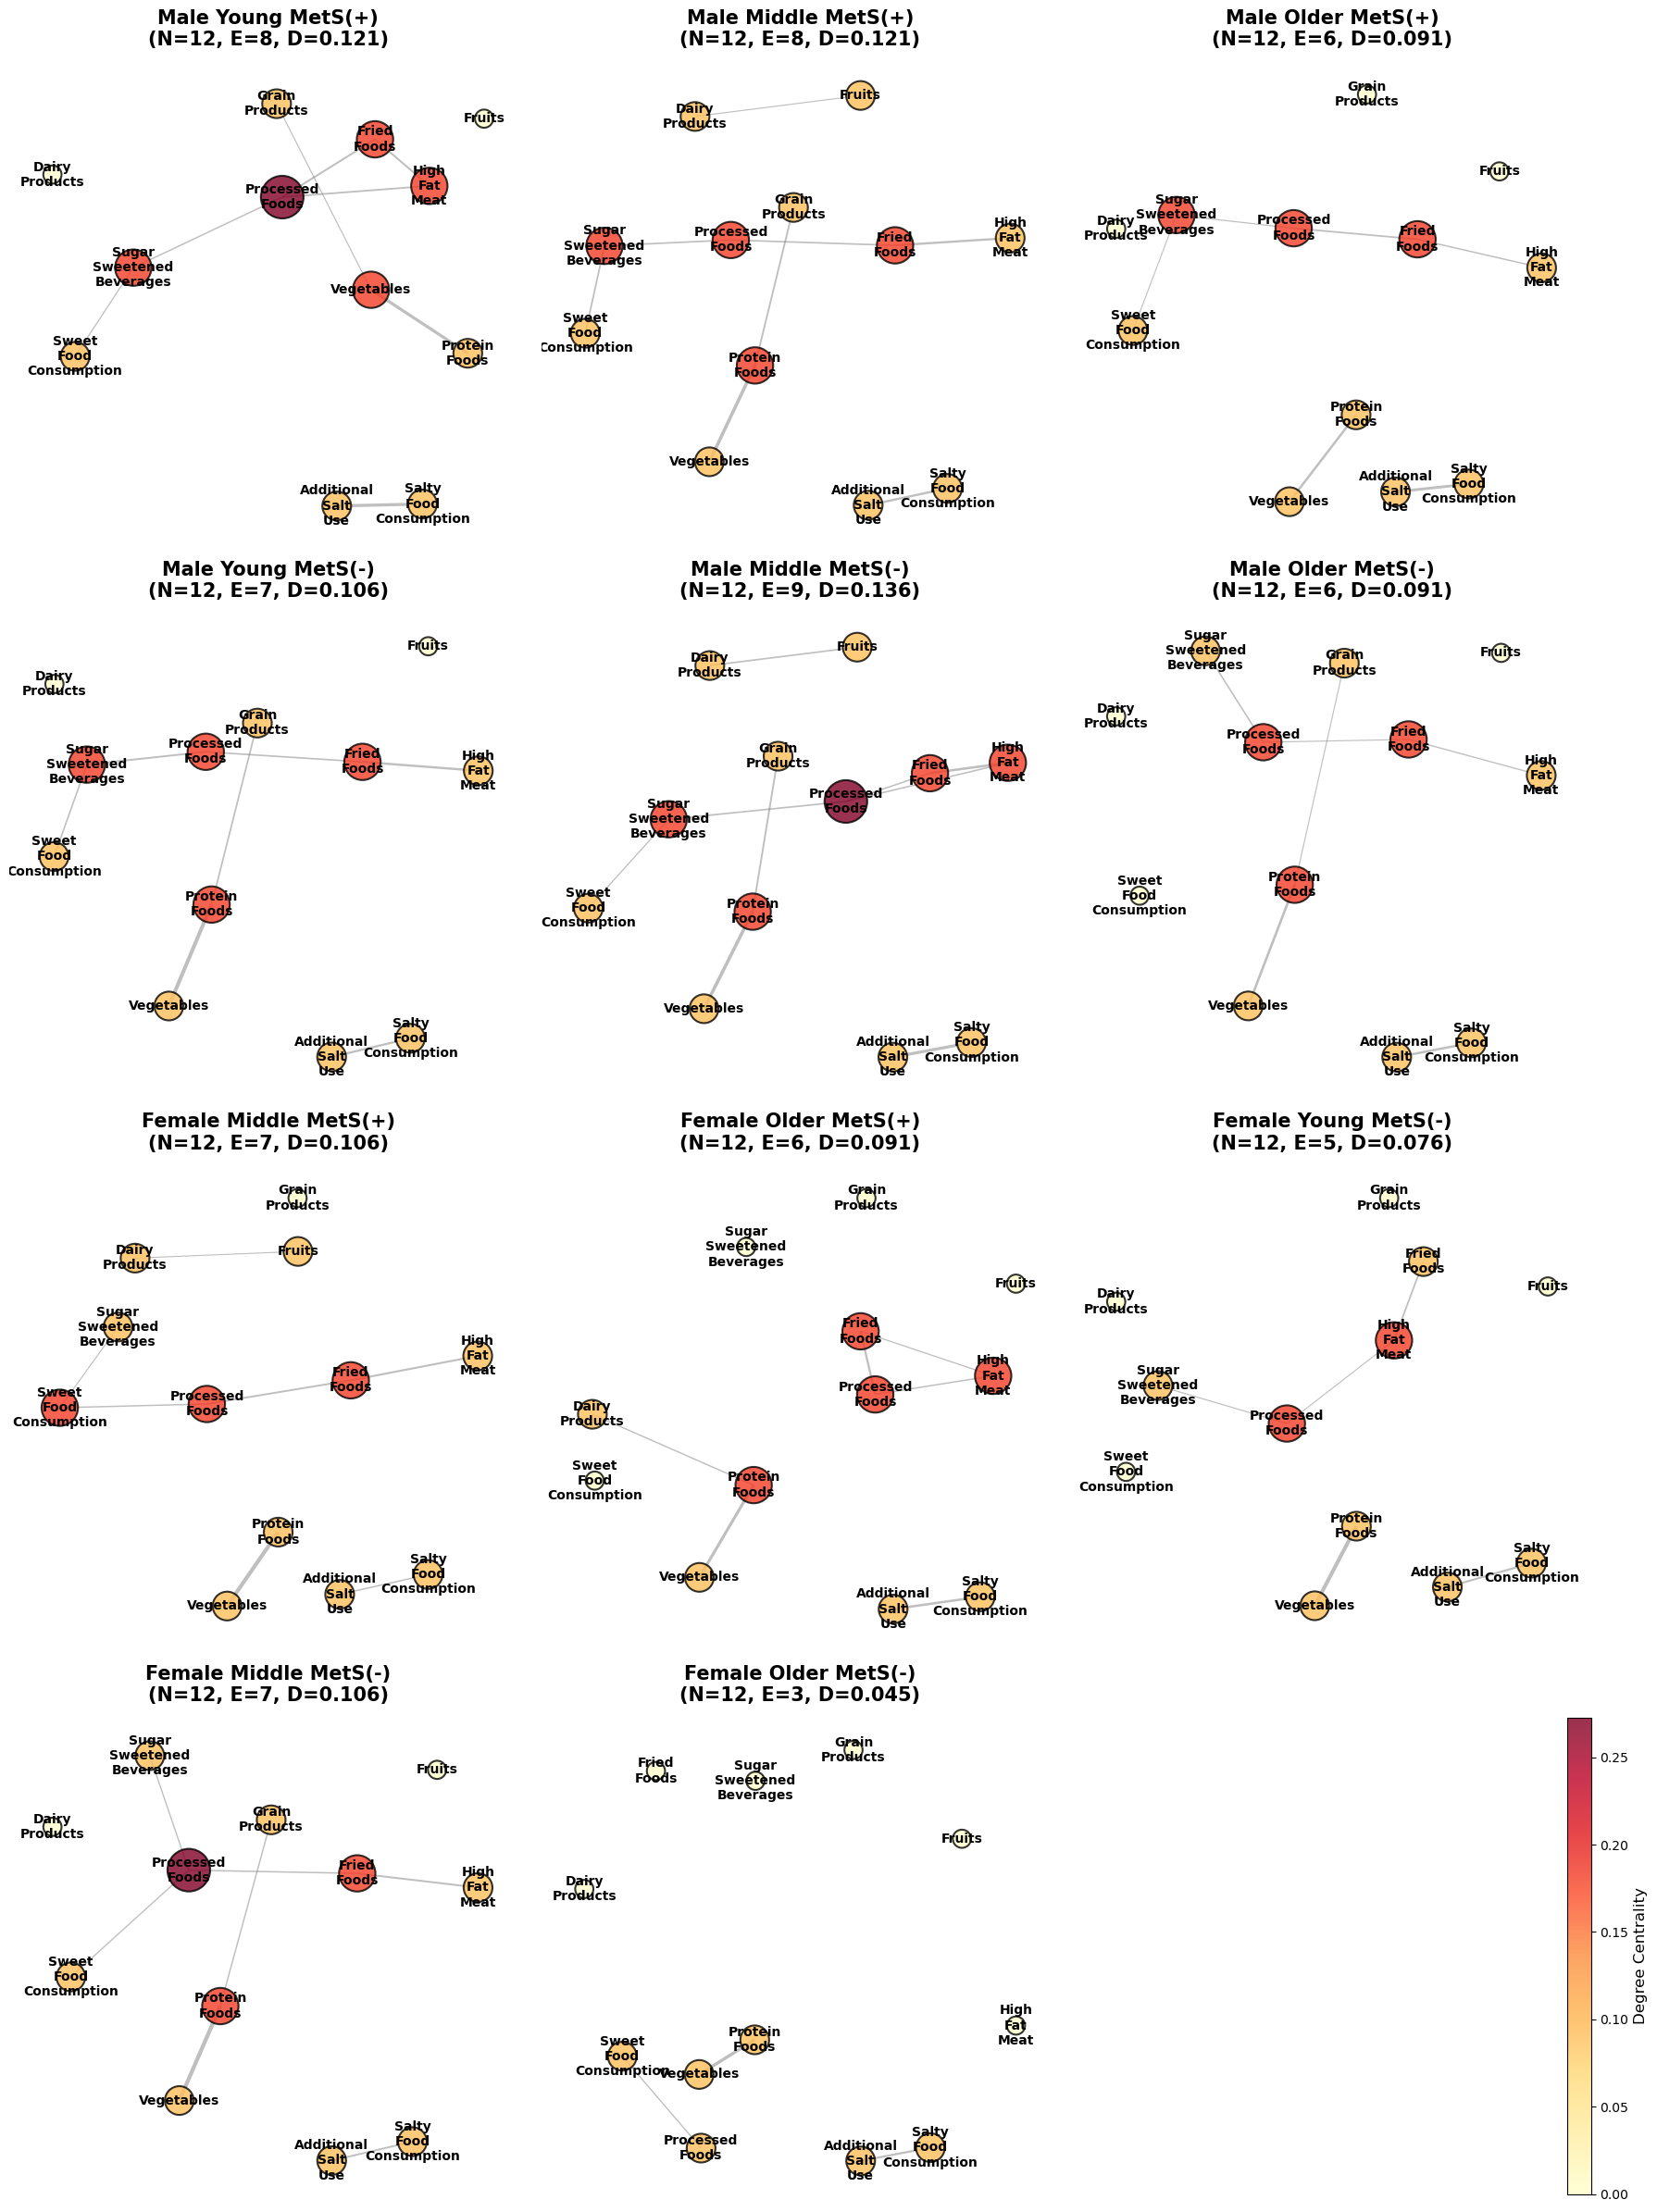

In [9]:
fig, axes = plt.subplots(4, 3, figsize=(18, 24))
axes = axes.flatten()

last_nodes = None
all_centralities = []

# Collect all centrality values
for sex, age_group, mets_status in GROUPS:
    G = load_network(sex, age_group, mets_status)
    if G is not None and G.number_of_nodes() > 0:
        centrality = nx.degree_centrality(G)
        all_centralities.extend(centrality.values())

# Calculate vmin/vmax from actual data
vmin = min(all_centralities) if all_centralities else 0
vmax = max(all_centralities) if all_centralities else 1
print(f"  Centrality range: {vmin:.3f} - {vmax:.3f}")

# Create network images
for idx, (sex, age_group, mets_status) in enumerate(GROUPS):
    ax = axes[idx]
    G = load_network(sex, age_group, mets_status)
    
    if G is None or G.number_of_nodes() == 0:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', fontsize=12)
        ax.set_title(GROUP_LABELS[idx], fontsize=10, fontweight='bold')
        ax.axis('off')
        continue
    
    pos = nx.spring_layout(G, k=0.5, iterations=50, seed=42) # Force-directed layout
    
    # Node sizes based on degree
    degrees = dict(G.degree())
    node_sizes = [degrees[node] * 300 + 200 for node in G.nodes()]
    
    # Node colors based on degree centrality
    centrality = nx.degree_centrality(G)
    node_colors = [centrality[node] for node in G.nodes()]
    
    # Draw edges with varying widths based on partial correlation
    for u, v, data in G.edges(data=True):
        weight = data.get('weight', 1.0)
        nx.draw_networkx_edges(
            G, pos, [(u, v)], 
            ax=ax, 
            alpha=0.5, 
            width=weight * 8,
            edge_color='gray'
        )
    
    # Draw nodes with adjusted vmin/vmax
    nodes = nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_size=node_sizes,
        node_color=node_colors,
        cmap='YlOrRd',
        vmin=vmin, vmax=vmax,
        alpha=0.8,
        edgecolors='black',
        linewidths=1.5
    )
    last_nodes = nodes
    
    # Draw labels with automatic line breaks
    labels = {}
    for node in G.nodes():
        label = node.replace(' ', '\n').replace('-', '\n')
        labels[node] = label

    nx.draw_networkx_labels(G, pos, labels, ax=ax, font_size=10, font_weight='bold')
    
    ax.margins(0.1)

    # Title
    title = GROUP_LABELS[idx].replace('_', ' ')
    n_nodes = G.number_of_nodes()
    n_edges = G.number_of_edges()
    density = nx.density(G)
    
    ax.set_title(
        f"{title}\n(N={n_nodes}, E={n_edges}, D={density:.3f})",
        fontsize=15,
        fontweight='bold'
    )
    ax.axis('off')

# Hide unused subplots
for idx in range(len(GROUPS), len(axes)):
    axes[idx].axis('off')

# Add colorbar
if last_nodes is not None:
    cbar = plt.colorbar(last_nodes, ax=axes[-1], fraction=0.046, pad=0.04)
    cbar.set_label('Degree Centrality', fontsize=12)

plt.tight_layout()
output_file = FIGURES_DIR / 'Figure_1_Network_Visualizations_GGM.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight', facecolor='none', transparent=True)
#plt.close()

## FIGURE 2: Hub Food Centrality Comparison

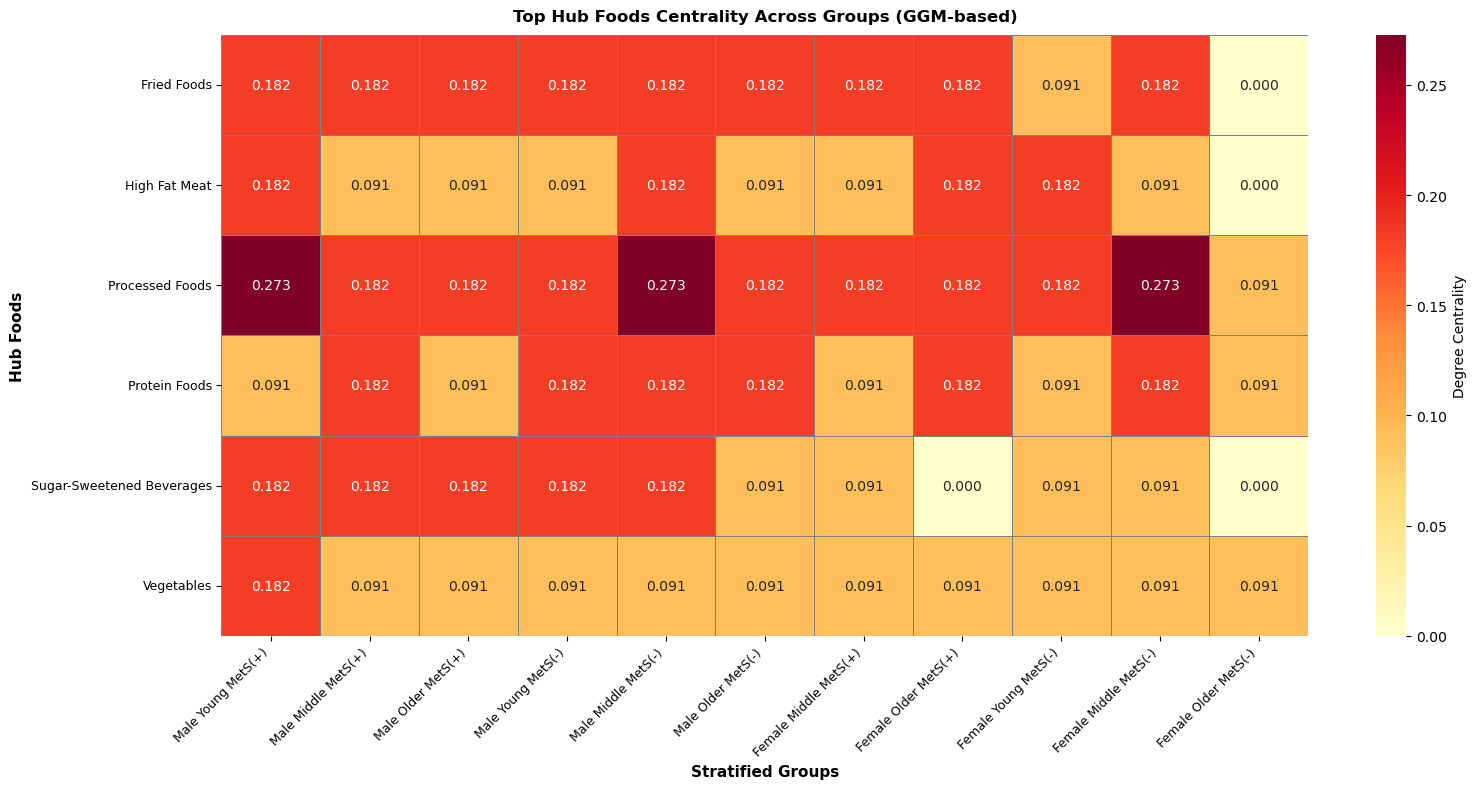

In [10]:
data = []
all_foods = set()

for idx, (sex, age_group, mets_status) in enumerate(GROUPS):
    G = load_network(sex, age_group, mets_status)
    if G is None:
        continue
    
    centrality = nx.degree_centrality(G)
    for food, cent_value in centrality.items():
        all_foods.add(food)
        data.append({
            'Group': GROUP_LABELS[idx].replace('_', ' '),
            'Food': food,
            'Centrality': cent_value
        })

df = pd.DataFrame(data)

# Top hub foods 선택
food_avg_centrality = df.groupby('Food')['Centrality'].mean().sort_values(ascending=False)
top_hub_foods = food_avg_centrality.head(6).index.tolist()

# 피벗 테이블 생성 (Food x Group)
df_top_hubs = df[df['Food'].isin(top_hub_foods)]
heatmap_data = df_top_hubs.pivot_table(
    index='Food', 
    columns='Group', 
    values='Centrality', 
    fill_value=0
)

# 그룹 순서 맞추기
group_labels_clean = [g.replace('_', ' ') for g in GROUP_LABELS]
heatmap_data = heatmap_data[group_labels_clean]

# 히트맵 그리기
fig, ax = plt.subplots(1, 1, figsize=(16, 8))

import seaborn as sns
sns.heatmap(
    heatmap_data, 
    annot=True,  # 값 표시
    fmt='.3f',  # 소수점 3자리
    cmap='YlOrRd',  # 색상 맵
    cbar_kws={'label': 'Degree Centrality'},
    linewidths=0.5,  # 셀 구분선
    linecolor='gray',
    ax=ax,
    vmin=0,
    vmax=heatmap_data.values.max()
)

ax.set_xlabel('Stratified Groups', fontsize=11, fontweight='bold')
ax.set_ylabel('Hub Foods', fontsize=11, fontweight='bold')
ax.set_title('Top Hub Foods Centrality Across Groups (GGM-based)', fontsize=12, fontweight='bold', pad=10)

# X축 라벨 회전
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
output_file = FIGURES_DIR / 'Figure_2_Hub_Centrality_Comparison_GGM.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight', facecolor='white')
#plt.close()


## FIGURE 3

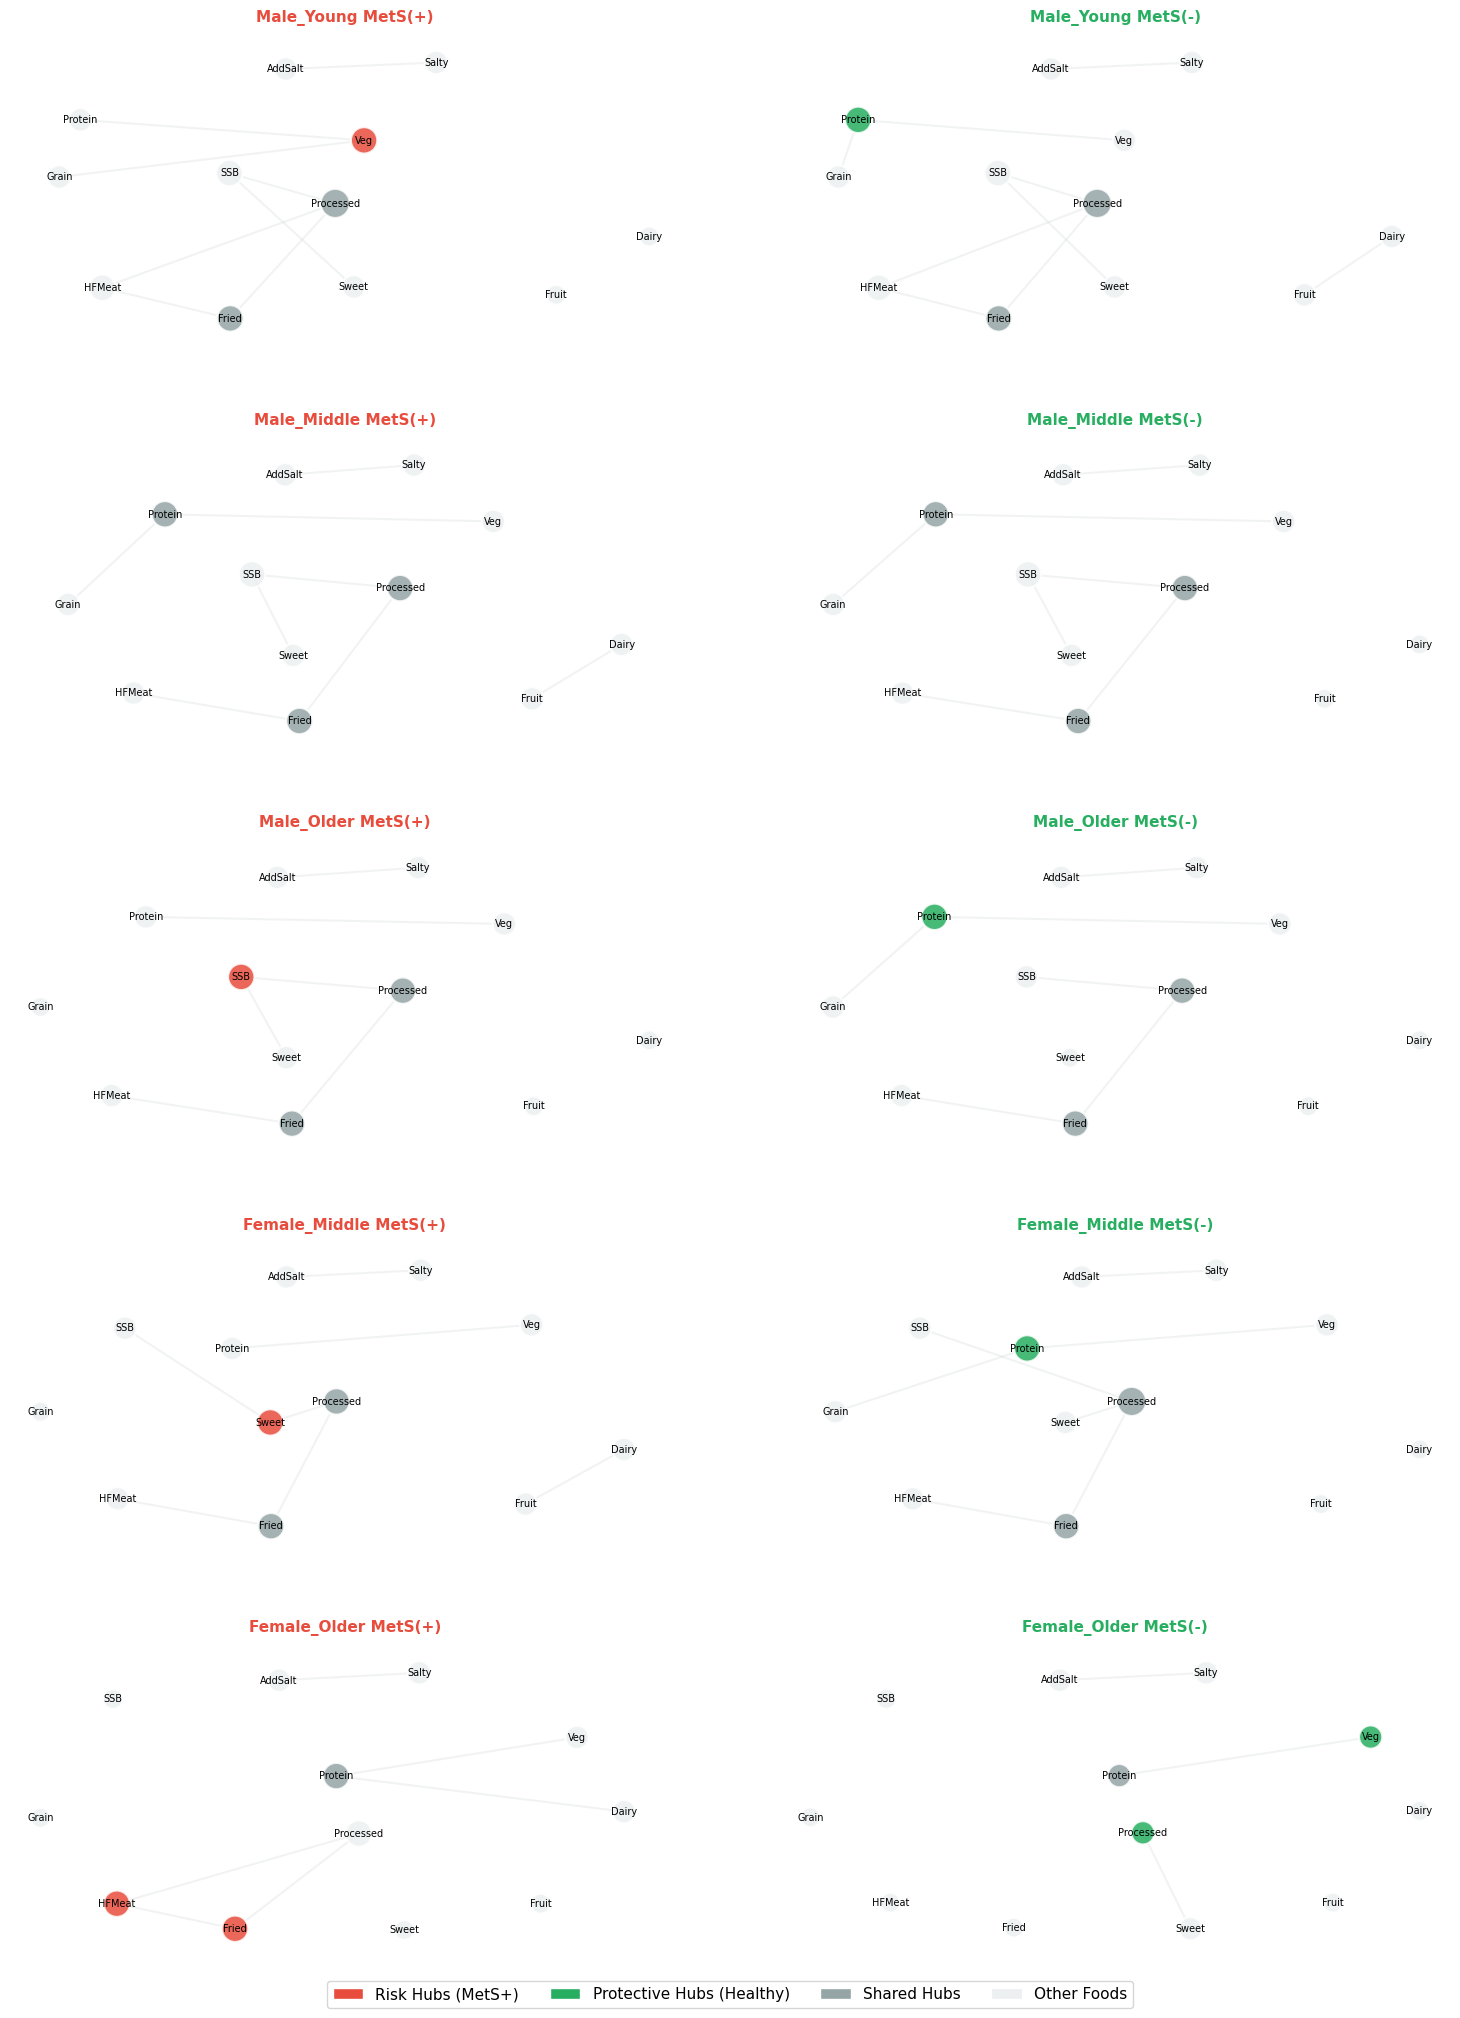

In [26]:
# Color scheme
RISK_COLOR = '#E74C3C'          # Red for Risk Hubs (REDUCE)
PROTECTIVE_COLOR = '#27AE60'    # Green for Protective Hubs (PROMOTE)
SHARED_COLOR = '#95A5A6'        # Gray for Shared Hubs
OTHER_COLOR = '#ECF0F1'         # Light gray for other foods
EDGE_COLOR = '#BDC3C7'          # Gray for edges

# Food abbreviations
FOOD_ABBREV = {
    'Grain Products': 'Grain',
    'Protein Foods': 'Protein',
    'Vegetables': 'Veg',
    'Dairy Products': 'Dairy',
    'Fruits': 'Fruit',
    'Fried Foods': 'Fried',
    'High Fat Meat': 'HFMeat',
    'Processed Foods': 'Processed',
    'Sugar-Sweetened Beverages': 'SSB',
    'Additional Salt Use': 'AddSalt',
    'Salty Food Consumption': 'Salty',
    'Sweet Food Consumption': 'Sweet'
}

def parse_hub_list(hub_string):
    if pd.isna(hub_string) or hub_string == 'None' or hub_string == 'N/A':
        return []
    return [h.strip() for h in str(hub_string).split(',')]

def get_node_color(node, risk_hubs, protective_hubs, shared_hubs):
    if node in risk_hubs:
        return RISK_COLOR
    elif node in protective_hubs:
        return PROTECTIVE_COLOR
    elif node in shared_hubs:
        return SHARED_COLOR
    else:
        return OTHER_COLOR

def draw_network_subplot(ax, G, pos, risk_hubs, protective_hubs, shared_hubs, hub_degrees, title, metrics_color):
    node_colors = [get_node_color(node, risk_hubs, protective_hubs, shared_hubs) for node in G.nodes()]
    hub_nodes = set(risk_hubs + protective_hubs + shared_hubs)
    node_sizes = []
    for node in G.nodes():
        degree = G.degree(node)
        node_sizes.append(degree * 80 + 200)
    
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.2, width=1.5, edge_color=EDGE_COLOR)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=node_sizes, 
                           alpha=0.85, edgecolors='white', linewidths=1.5)
    
    labels = {node: FOOD_ABBREV.get(node, node[:8]) for node in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels, ax=ax, font_size=7, font_weight='normal')
    
    ax.set_title(title, fontsize=11, fontweight='bold', pad=10, color=metrics_color)
    ax.axis('off')

# Load data
table_s3 = pd.read_csv(TABLES_DIR / 'Table_S3_Personalized_Coaching_Strategies.csv')
network_summary = pd.read_csv(NETWORK_DIR / 'ggm_network_summary.csv')
groups_to_plot = [
    ('남성', '청년층(19-39세)', 'Male', 'Young (19-39y)', 'Male_Young'),
    ('남성', '중년층(40-59세)', 'Male', 'Middle-aged (40-59y)', 'Male_Middle'),
    ('남성', '장년층(60-74세)', 'Male', 'Older (60-74y)', 'Male_Older'),
    ('여성', '중년층(40-59세)', 'Female', 'Middle-aged (40-59y)', 'Female_Middle'),
    ('여성', '장년층(60-74세)', 'Female', 'Older (60-74y)', 'Female_Older'),
]

fig, axes = plt.subplots(5, 2, figsize=(16, 20))
plt.subplots_adjust(left=0.05, right=0.95, top=0.98, bottom=0.02, hspace=0.3, wspace=0.15)

for row, (sex_kr, age_kr, sex_en, age_en, label) in enumerate(groups_to_plot):
    s3_row = table_s3[(table_s3['Sex'] == sex_en) & (table_s3['Age_Group'] == age_en)].iloc[0]
    
    risk_hubs = parse_hub_list(s3_row['Risk_Hubs_in_MetS'])
    protective_hubs = parse_hub_list(s3_row['Protective_Hubs_in_Healthy'])
    shared_hubs = parse_hub_list(s3_row['Shared_Hubs'])
    
    G_plus = load_network(sex_kr, age_kr, 'MetS(+)')
    G_minus = load_network(sex_kr, age_kr, 'MetS(-)')
    
    # Get network statistics
    group_plus = f"{sex_kr}_{age_kr}_MetS(+)"
    group_minus = f"{sex_kr}_{age_kr}_MetS(-)"
    
    plus_row = network_summary[network_summary['Group'] == group_plus].iloc[0]
    minus_row = network_summary[network_summary['Group'] == group_minus].iloc[0]
    
    # Hub degrees (for node sizing)
    hub_degrees_plus = {
        plus_row['Hub_1_Name']: plus_row['Hub_1_Degree'],
        plus_row['Hub_2_Name']: plus_row['Hub_2_Degree'],
        plus_row['Hub_3_Name']: plus_row['Hub_3_Degree'],
    }
    
    hub_degrees_minus = {
        minus_row['Hub_1_Name']: minus_row['Hub_1_Degree'],
        minus_row['Hub_2_Name']: minus_row['Hub_2_Degree'],
        minus_row['Hub_3_Name']: minus_row['Hub_3_Degree'],
    }
    
    # Create consistent layout using combined graph
    all_nodes = list(set(list(G_plus.nodes()) + list(G_minus.nodes())))
    G_combined = nx.Graph()
    G_combined.add_nodes_from(all_nodes)
    G_combined.add_edges_from(G_plus.edges())
    G_combined.add_edges_from(G_minus.edges())
    pos = nx.spring_layout(G_combined, seed=42, k=2.5, iterations=100)
    
    # Draw MetS(+) network (left column)
    draw_network_subplot(
        axes[row, 0], G_plus, pos, risk_hubs, [], shared_hubs, 
        hub_degrees_plus, f'{label} MetS(+)', RISK_COLOR
    )
    
    # Draw MetS(-) network (right column)
    draw_network_subplot(
        axes[row, 1], G_minus, pos, [], protective_hubs, shared_hubs, 
        hub_degrees_minus, f'{label} MetS(-)', PROTECTIVE_COLOR
    )

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=RISK_COLOR, edgecolor='white', label='Risk Hubs (MetS+)'),
    Patch(facecolor=PROTECTIVE_COLOR, edgecolor='white', label='Protective Hubs (Healthy)'),
    Patch(facecolor=SHARED_COLOR, edgecolor='white', label='Shared Hubs'),
    Patch(facecolor=OTHER_COLOR, edgecolor='white', label='Other Foods')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4, 
            frameon=True, fontsize=11, bbox_to_anchor=(0.5, -0.01))

# Save figure
output_path = FIGURES_DIR / 'Figure_3_Individual_Networks_Grid.png'
fig.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')

## FIGURE S1: Partial Correlation Heatmaps

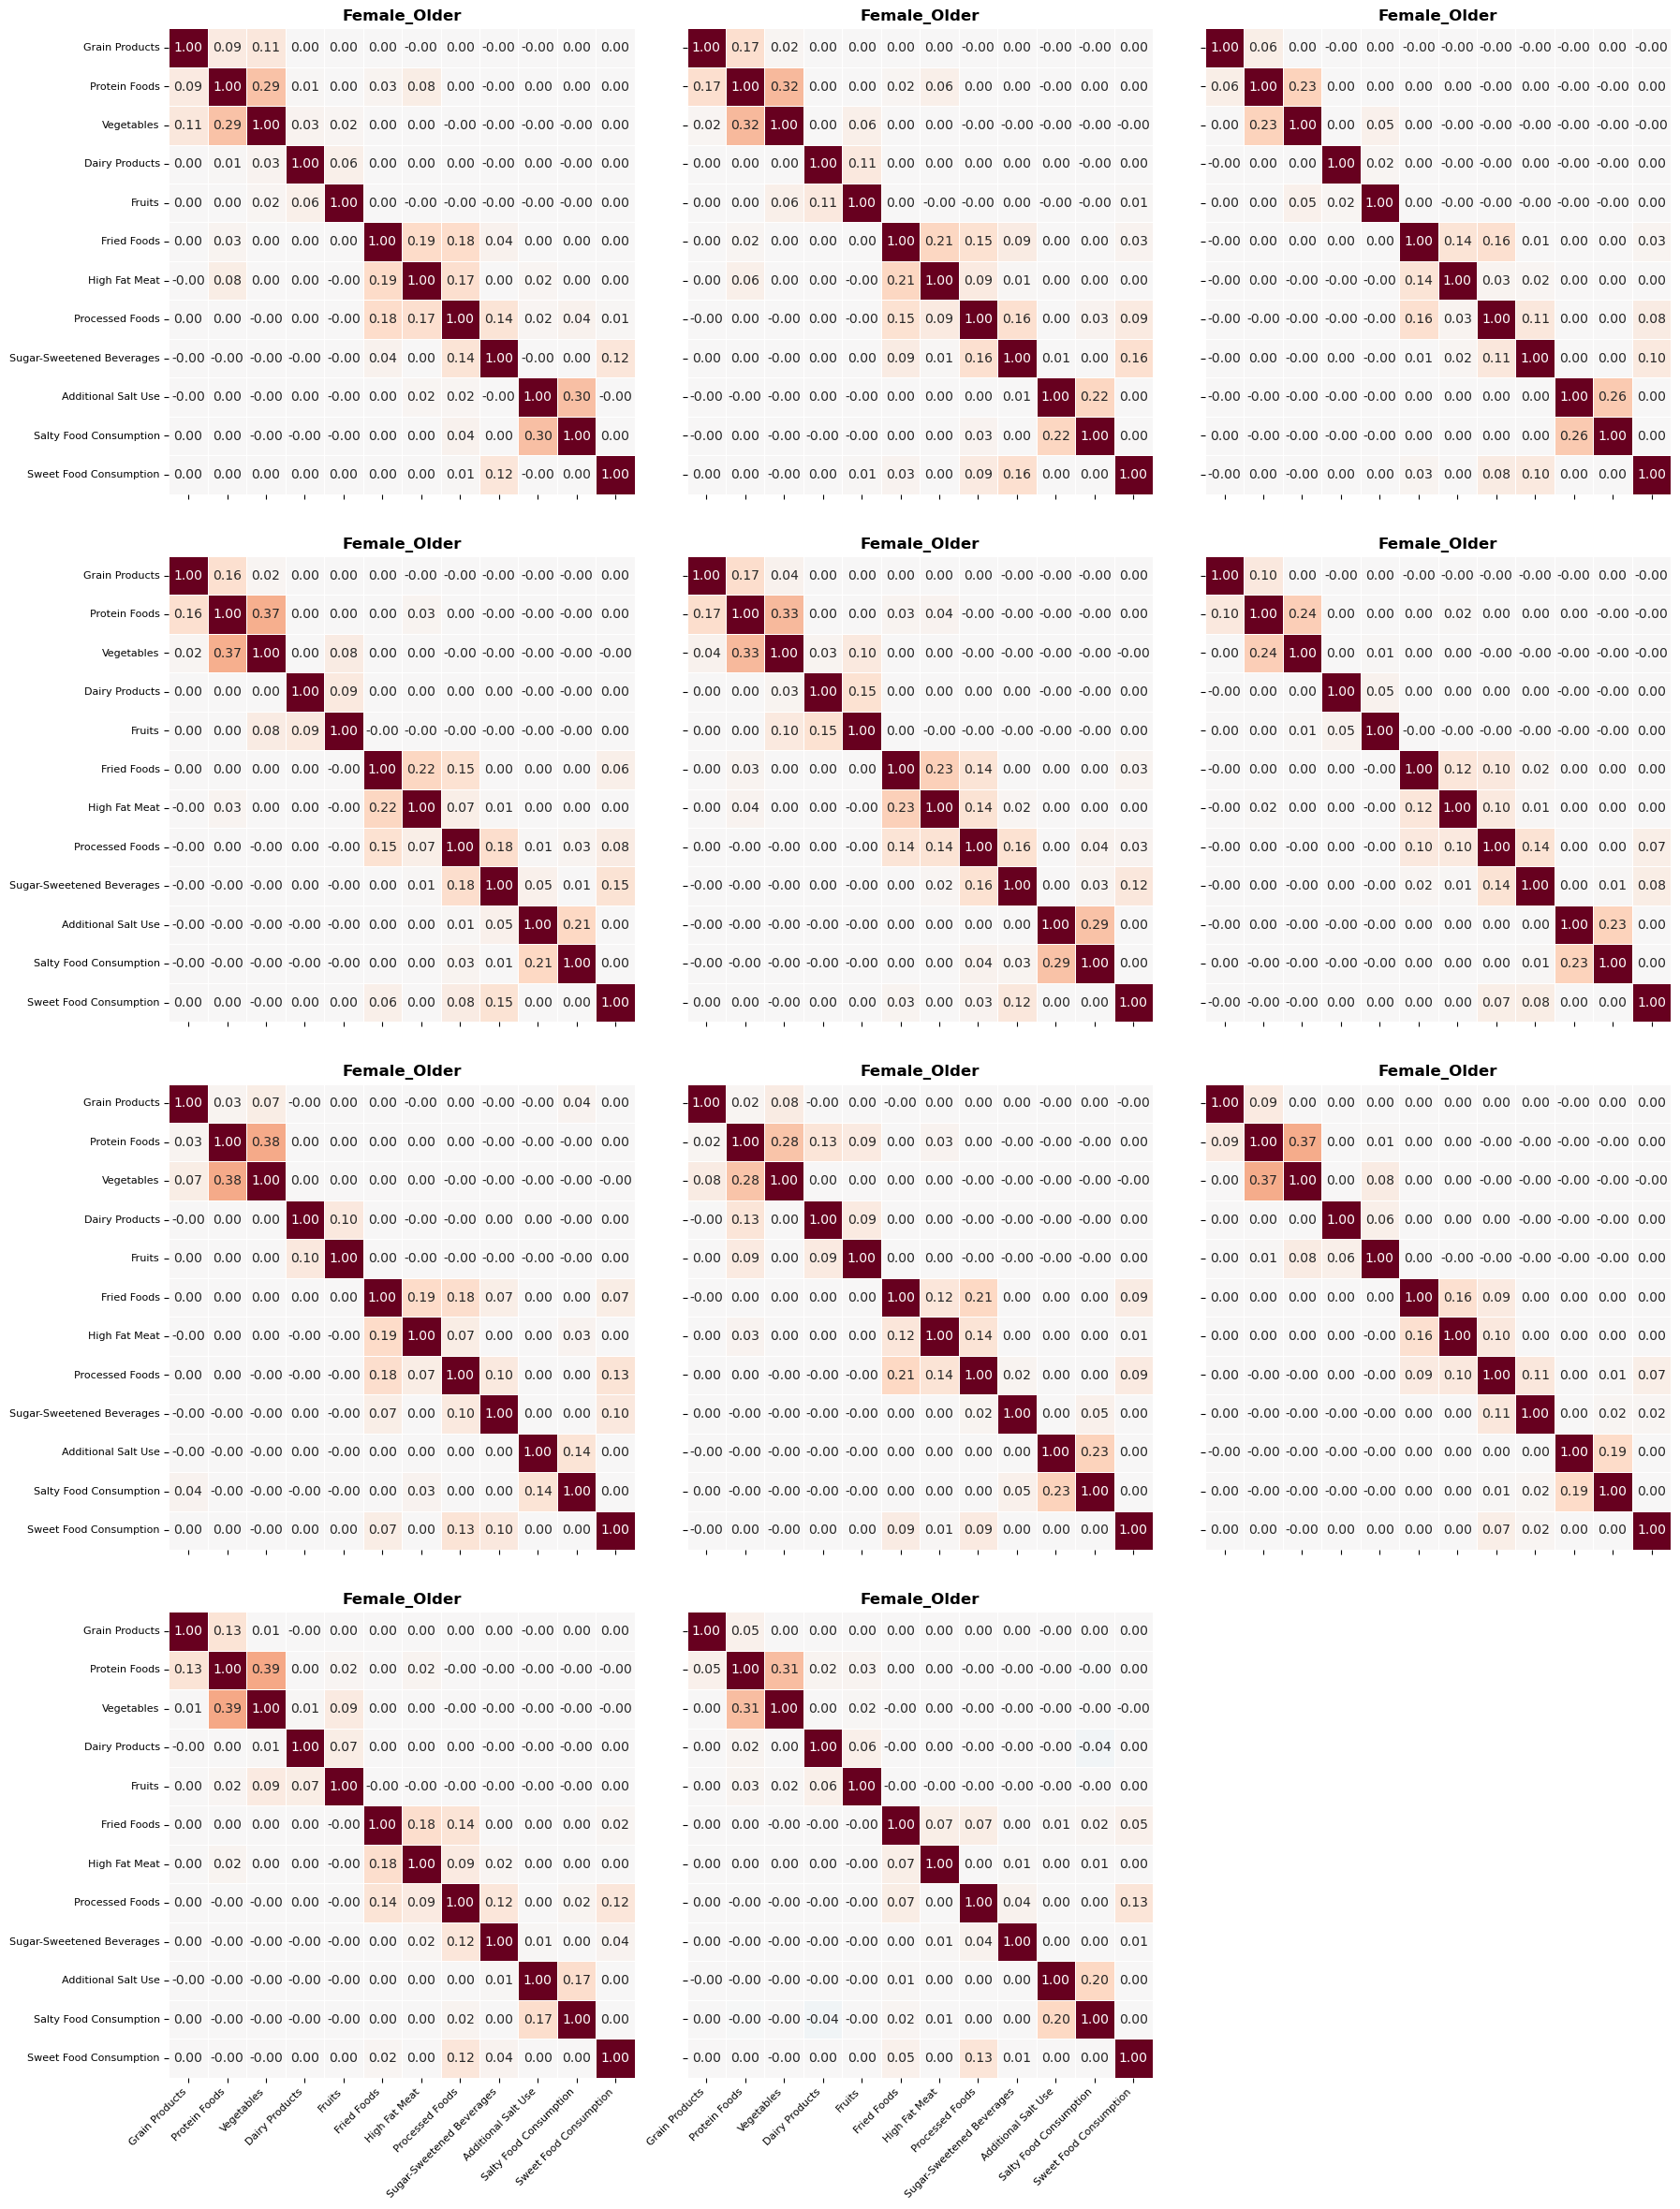

In [12]:
fig, axes = plt.subplots(4, 3, figsize=(18, 24), sharex=True, sharey=True)
axes = axes.flatten()

for idx, (sex, age_group, mets_status) in enumerate(GROUPS):
    ax = axes[idx]
    
    partial_corr_df = load_partial_corr_matrix(sex, age_group, mets_status)
    
    show_cbar = (idx == 12)
    
    sns.heatmap(
        partial_corr_df,
        cmap='RdBu_r',
        center=0,
        annot=True,
        fmt='.2f',
        linewidths=0.5,
        cbar=show_cbar,
        cbar_kws={'label': 'Partial Correlation'} if show_cbar else None,
        ax=ax,
        vmin=-1,
        vmax=1,
        square=True
    )
    
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')

for idx in range(9, 12):
    axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha='right', fontsize=8)
for idx in [0, 3, 6, 9]:
    axes[idx].set_yticklabels(axes[idx].get_yticklabels(), rotation=0, fontsize=8)

# Hide unused subplots
for idx in range(len(GROUPS), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
output_file = FIGURES_DIR / 'Supplementary_Figure_1_Partial_Correlation_Heatmaps_GGM.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight', facecolor='white')

## FIGURE S2: Community Structure Analysis

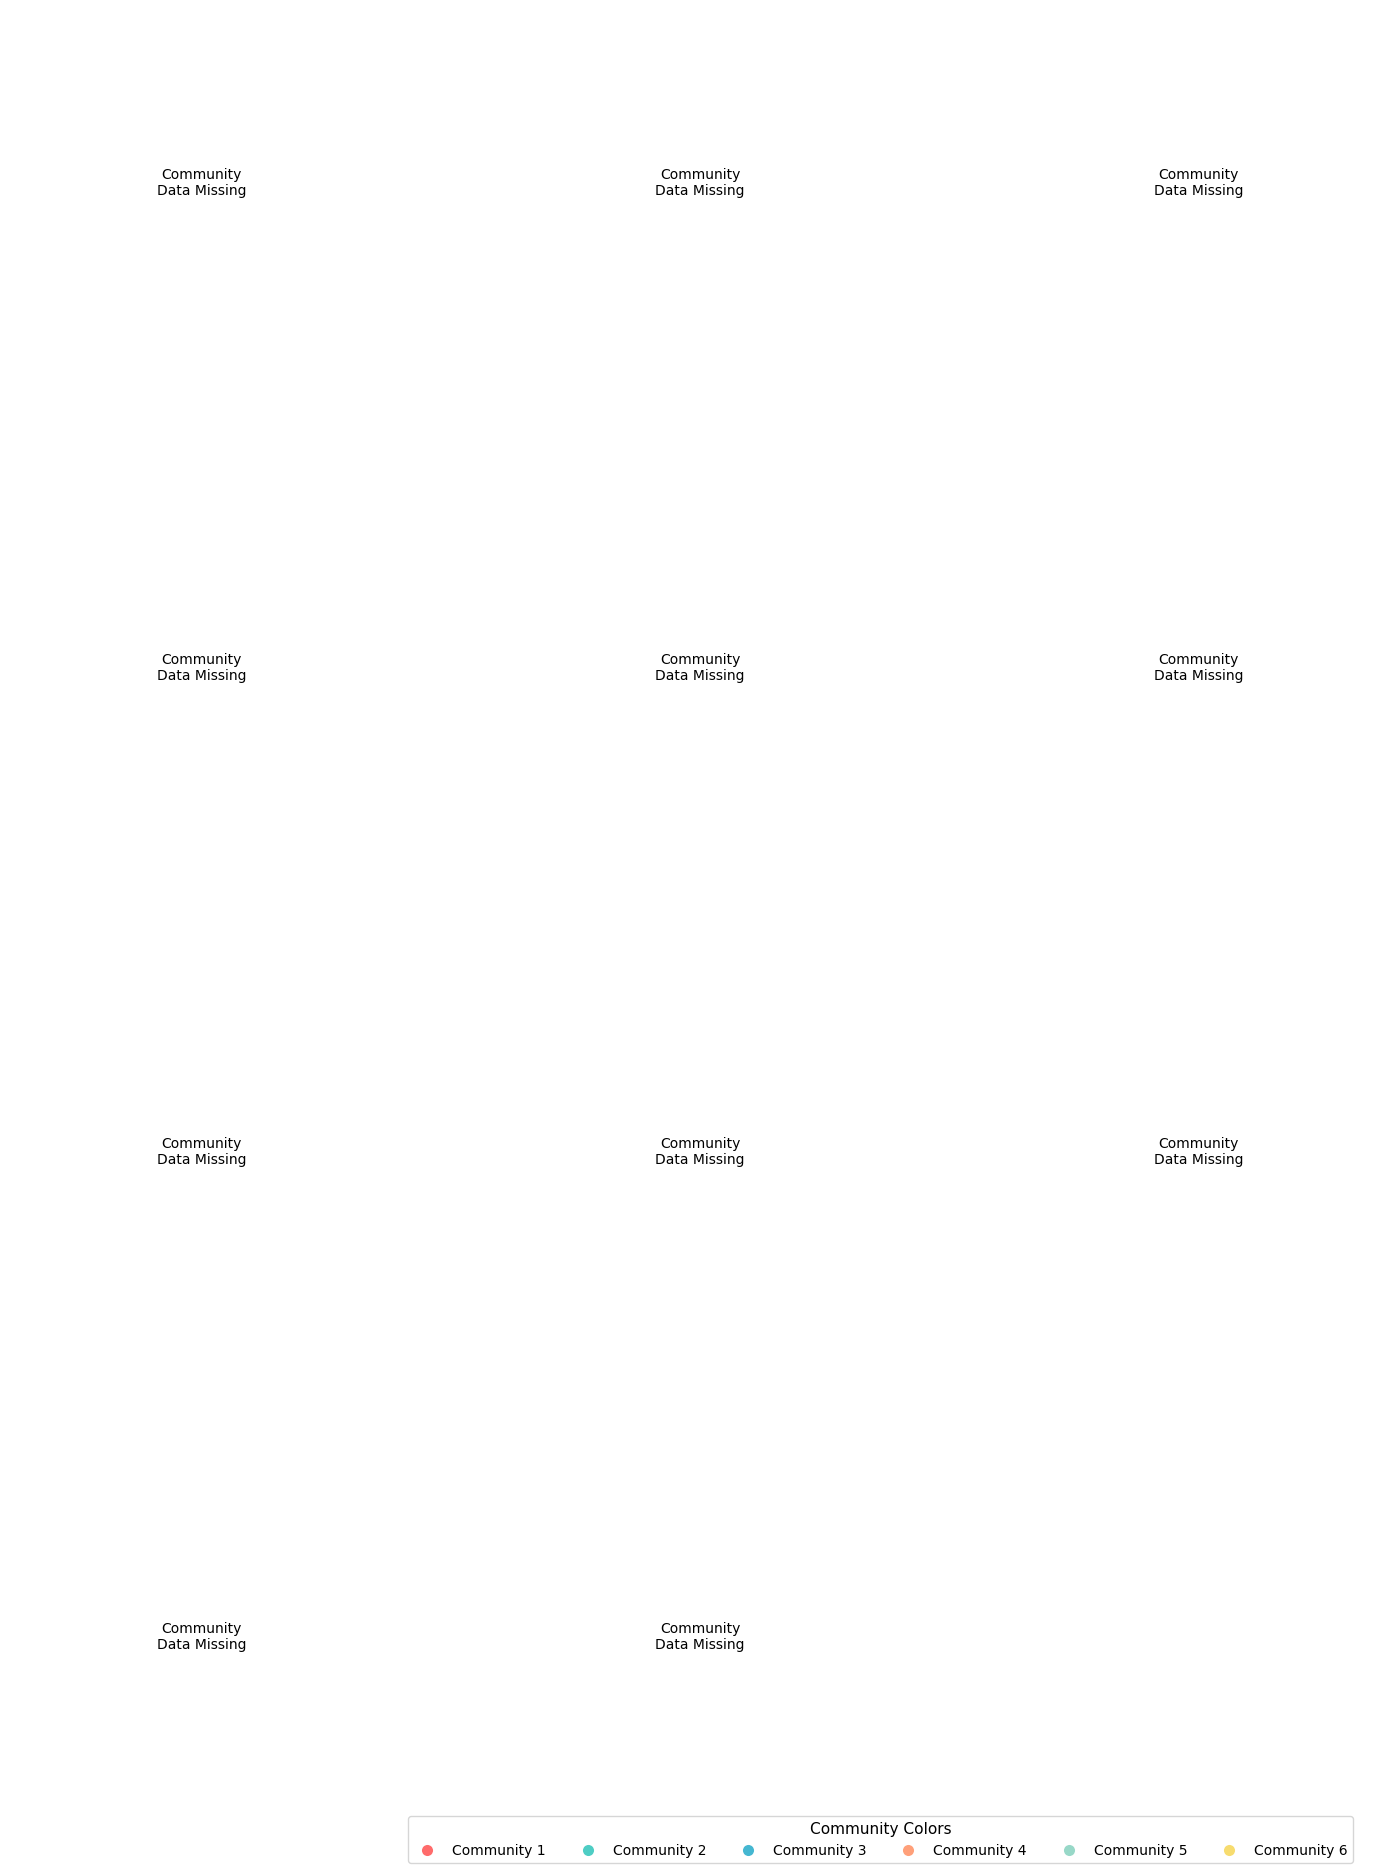

In [13]:
COMMUNITY_COLORS = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#F7DC6F']

summary_df = load_statistics()
fig = plt.figure(figsize=(15, 20))
gs = fig.add_gridspec(4, 3, hspace=0.4, wspace=0.3, left=0.05, right=0.97, top=0.95, bottom=0.05)

for idx, ((sex, age_group, mets_status), label) in enumerate(zip(GROUPS, GROUP_LABELS)):
    row = idx // 3
    col = idx % 3
    ax = fig.add_subplot(gs[row, col])
    
    G = load_network(sex, age_group, mets_status)
    if G is None:
        ax.text(0.5, 0.5, 'Network\nNot Found', ha='center', va='center', fontsize=10, transform=ax.transAxes)
        ax.axis('off')
        continue
    
    group = f"{sex}_{age_group}_{mets_status}"
    
    comm_file = NETWORK_DIR / f"ggm_network_{group}_communities.csv"
    if not comm_file.exists():
        print(f"  Warning: Community file not found: {comm_file}")
        ax.text(0.5, 0.5, 'Community\nData Missing', ha='center', va='center', fontsize=10, transform=ax.transAxes)
        ax.axis('off')
        continue
    
    comm_df = pd.read_csv(comm_file)
    
    # Create node-to-community mapping
    node_colors = {}
    for _, row_data in comm_df.iterrows():
        comm_id = row_data['community_id']
        nodes = row_data['nodes'].split('; ')
        color = COMMUNITY_COLORS[(comm_id - 1) % len(COMMUNITY_COLORS)]
        for node in nodes:
            node_colors[node] = color
    
    colors = [node_colors.get(node, '#CCCCCC') for node in G.nodes()]
    pos = nx.spring_layout(G, seed=42, k=1.5, iterations=50)
    
    # Draw network
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.3, width=1.5, edge_color='gray')
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colors, node_size=400, alpha=0.9, edgecolors='white', linewidths=2)
    
    labels_dict = {node: FOOD_ABBREV.get(node, node[:4]) for node in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels_dict, ax=ax, font_size=7, font_weight='bold')
    
    # Title
    n_comm = len(comm_df)
    modularity = summary_df[summary_df['Group'] == group]['Modularity'].values[0]
    ax.set_title(f"{label}\n{n_comm} communities (Q={modularity:.3f})", 
                fontsize=10, fontweight='bold', pad=8)
    ax.axis('off')

# Add legend for community colors
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=COMMUNITY_COLORS[i],
                markersize=10, label=f'Community {i+1}', 
                markeredgewidth=2, markeredgecolor='white')
    for i in range(6)
]
fig.legend(handles=legend_elements, loc='lower right', ncol=6,
            frameon=True, fontsize=10, bbox_to_anchor=(0.95, 0.02),
            title='Community Colors', title_fontsize=11)

# Save
output_file = FIGURES_DIR / 'Supplementary_Figure_2_Community_Structure.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight', facecolor='white')

## FIGURE S3: Metabolic Syndrome Effects on Dietary Network Structure

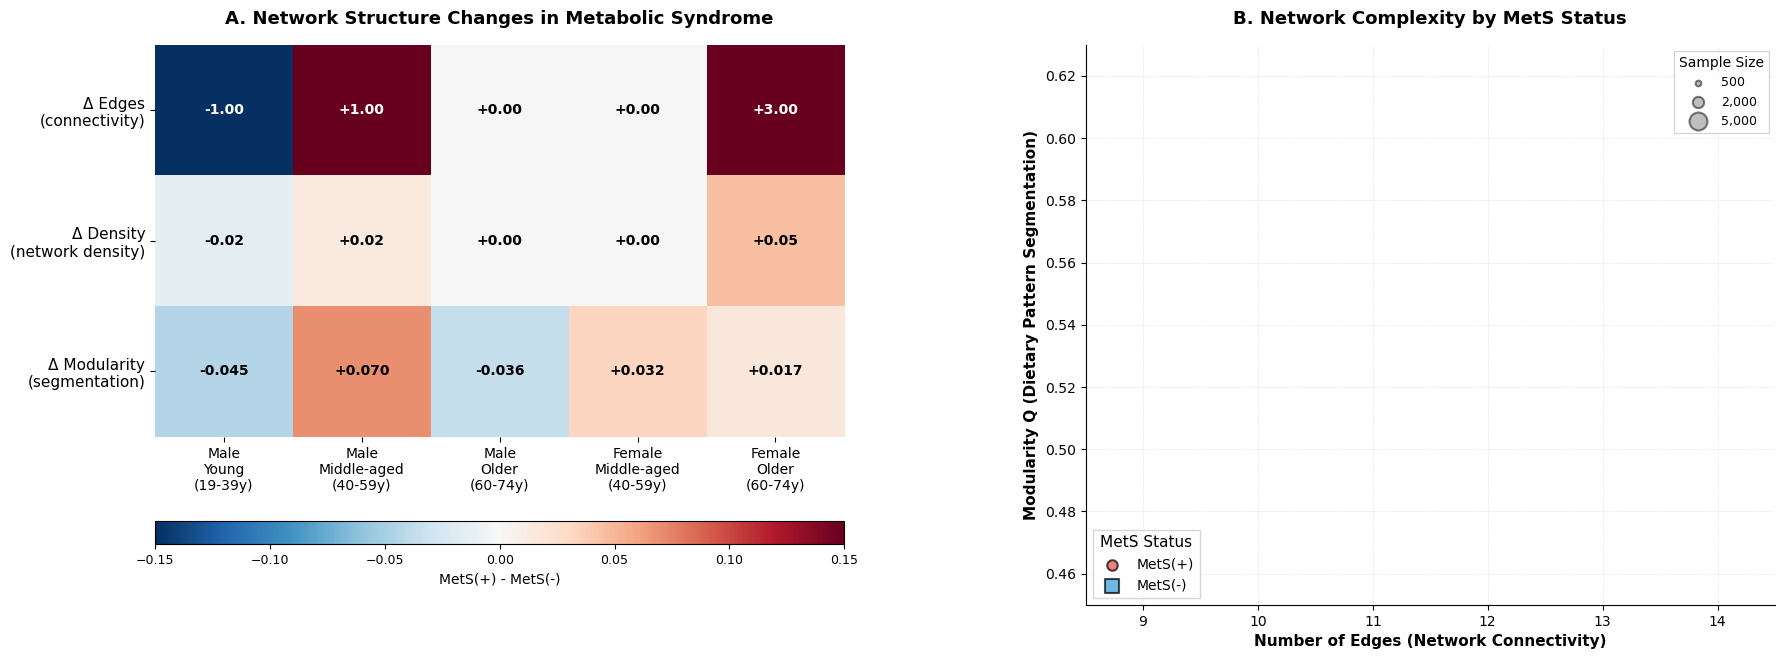

In [14]:
def prepare_mets_differences(network_df):
    groups = [
        ('Male', 'Young\n(19-39y)', '남성_청년층(19-39세)'),
        ('Male', 'Middle-aged\n(40-59y)', '남성_중년층(40-59세)'),
        ('Male', 'Older\n(60-74y)', '남성_장년층(60-74세)'),
        ('Female', 'Young\n(19-39y)', '여성_청년층(19-39세)'),
        ('Female', 'Middle-aged\n(40-59y)', '여성_중년층(40-59세)'),
        ('Female', 'Older\n(60-74y)', '여성_장년층(60-74세)'),
    ]
    
    results = []
    for sex, age_label, group_prefix in groups:
        mets_plus = network_df[network_df['Group'] == f"{group_prefix}_MetS(+)"]
        mets_minus = network_df[network_df['Group'] == f"{group_prefix}_MetS(-)"]
        
        if len(mets_plus) == 0 or len(mets_minus) == 0:
            results.append({
                'Sex': sex,
                'Age': age_label,
                'Delta_Edges': np.nan,
                'Delta_Density': np.nan,
                'Delta_Modularity': np.nan,
                'Delta_Communities': np.nan,
                'N_Plus': 0,
                'N_Minus': mets_minus.iloc[0]['N_Samples'] if len(mets_minus) > 0 else 0
            })
        else:
            plus = mets_plus.iloc[0]
            minus = mets_minus.iloc[0]
            
            results.append({
                'Sex': sex,
                'Age': age_label,
                'Delta_Edges': plus['N_Edges'] - minus['N_Edges'],
                'Delta_Density': plus['Density'] - minus['Density'],
                'Delta_Modularity': plus['Modularity'] - minus['Modularity'],
                'Delta_Communities': plus['N_Communities'] - minus['N_Communities'],
                'N_Plus': plus['N_Samples'],
                'N_Minus': minus['N_Samples']
            })
    
    return pd.DataFrame(results)

def plot_panel_a_metrics_heatmap(ax, diff_df):
    diff_df_valid = diff_df.dropna(subset=['Delta_Edges'])
    diff_df_valid['Group'] = diff_df_valid['Sex'] + '\n' + diff_df_valid['Age']
    
    metrics = ['Delta_Edges', 'Delta_Density', 'Delta_Modularity']
    metric_labels = ['Δ Edges\n(connectivity)', 'Δ Density\n(network density)', 'Δ Modularity\n(segmentation)']
    
    # Create matrix
    matrix = diff_df_valid[metrics].values
    im = ax.imshow(matrix.T, cmap='RdBu_r', aspect='auto', vmin=-0.15, vmax=0.15)
    
    # Set ticks
    ax.set_xticks(range(len(diff_df_valid)))
    ax.set_xticklabels(diff_df_valid['Group'], rotation=0, ha='center', fontsize=10)
    ax.set_yticks(range(len(metrics)))
    ax.set_yticklabels(metric_labels, fontsize=11)
    
    # Add values as text
    for i in range(len(metrics)):
        for j in range(len(diff_df_valid)):
            value = matrix[j, i]
            if not np.isnan(value):
                text_color = 'white' if abs(value) > 0.08 else 'black'
                text = f'{value:+.2f}' if i < 2 else f'{value:+.3f}'
                ax.text(j, i, text,
                       ha='center', va='center', color=text_color, 
                       fontsize=10, weight='bold')
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.15, aspect=30)
    cbar.set_label('MetS(+) - MetS(-)', fontsize=10)
    cbar.ax.tick_params(labelsize=9)
    
    ax.set_title('A. Network Structure Changes in Metabolic Syndrome', 
                fontweight='bold', fontsize=13, pad=15)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

def plot_panel_b_network_complexity(ax, network_df):
    mets_plus = network_df[network_df['MetS_Status'] == 'MetS(+)']
    mets_minus = network_df[network_df['MetS_Status'] == 'MetS(-)']
    
    # Plot scatter
    scatter1 = ax.scatter(mets_plus['N_Edges'], mets_plus['Modularity'], 
                         s=mets_plus['N_Samples']/30, c='#E74C3C', alpha=0.7, 
                         edgecolors='black', linewidths=1.5, label='MetS(+)', marker='o')
    scatter2 = ax.scatter(mets_minus['N_Edges'], mets_minus['Modularity'], 
                         s=mets_minus['N_Samples']/30, c='#3498DB', alpha=0.7, 
                         edgecolors='black', linewidths=1.5, label='MetS(-)', marker='s')
    
    male_middle_plus = network_df[network_df['Group'] == '남성_중년층(40-59세)_MetS(+)'].iloc[0]
    male_middle_minus = network_df[network_df['Group'] == '남성_중년층(40-59세)_MetS(-)'].iloc[0]
    
    ax.annotate('Male 40-59y\nMetS(+)', 
                xy=(male_middle_plus['N_Edges'], male_middle_plus['Modularity']),
                xytext=(5, -15), textcoords='offset points', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.4', facecolor='#E74C3C', 
                         alpha=0.3, edgecolor='black', linewidth=1),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', lw=1))
    
    ax.annotate('Male 40-59y\nMetS(-)', 
                xy=(male_middle_minus['N_Edges'], male_middle_minus['Modularity']),
                xytext=(5, 10), textcoords='offset points', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.4', facecolor='#3498DB', 
                         alpha=0.3, edgecolor='black', linewidth=1),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', lw=1))
    
    # Axes labels
    ax.set_xlabel('Number of Edges (Network Connectivity)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Modularity Q (Dietary Pattern Segmentation)', fontsize=11, fontweight='bold')
    ax.set_xlim(8.5, 14.5)
    ax.set_ylim(0.45, 0.63)
    
    # Add legend for MetS status
    legend1 = ax.legend(loc='lower left', frameon=True, fancybox=False, 
                       fontsize=10, title='MetS Status', title_fontsize=11)
    
    # Add size legend
    sizes = [500, 2000, 5000]
    size_labels = ['500', '2,000', '5,000']
    legend_elements = [plt.scatter([], [], s=s/30, c='gray', alpha=0.5, 
                                  edgecolors='black', linewidths=1.5) 
                      for s in sizes]
    legend2 = ax.legend(legend_elements, size_labels, title='Sample Size', 
                       loc='upper right', frameon=True, fancybox=False, 
                       fontsize=9, title_fontsize=10)
    ax.add_artist(legend1)
    
    ax.set_title('B. Network Complexity by MetS Status', 
                fontweight='bold', fontsize=13, pad=15)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(alpha=0.3, linestyle='--', linewidth=0.5)

network_df = pd.read_csv('../result/networks/ggm_network_summary.csv')
diff_df = prepare_mets_differences(network_df)

fig = plt.figure(figsize=(18, 7))
gs = GridSpec(1, 2, figure=fig, hspace=0.30, wspace=0.35, left=0.06, right=0.96, top=0.90, bottom=0.10)

ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])

plot_panel_a_metrics_heatmap(ax_a, diff_df)
plot_panel_b_network_complexity(ax_b, network_df)

output_file = FIGURES_DIR / 'Supplementary_Figure_3_MetS_Network_Effects.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight', facecolor='white')